In [22]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os
import random
class SymbolGenerator:
    def __init__(self, data_path):
        self.data_path = data_path
        self.available_symbols = list(('(', ')', '0', '1', '2', '3', '4', '5', '6', '7', '8', '9', 't', 'x', 'y', ',', '+', '-', '*'))
        print("Доступные символы:", self.available_symbols)
        
    def get_random_symbol_image(self, char):
        folder_name = char
        if (char == 'x'):
            folder_name = 'X'
        if (char == '*'):
            folder_name = 'times'
        symbol_dir = os.path.join(self.data_path, folder_name)
        
        images = [f for f in os.listdir(symbol_dir)]
        images.sort() 
        start_index = int(len(images) * 0.8)
        last_30_percent = images[start_index:]

        random_image = random.choice(last_30_percent)
        img_path = os.path.join(symbol_dir, random_image)
        
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)    
        return img
    
    def generate_sequence(self, length=4):
        sequence = ''.join(random.choices(self.available_symbols, k=length))
        print(f"Генерируем: {sequence}")
        images = []
        
        for char in sequence:
            img = self.get_random_symbol_image(char)
            if img is not None:
                images.append(img)
        
        return sequence, images

generator = SymbolGenerator('C:\\dataset\\hw9\\')

Доступные символы: ['(', ')', '0', '1', '2', '3', '4', '5', '6', '7', '8', '9', 't', 'x', 'y', ',', '+', '-', '*']


In [6]:
def create_sequence_image(images, spacing=20):
    total_width = sum(img.shape[1] for img in images) + spacing * (len(images) - 1)
    max_height = max(img.shape[0] for img in images)
    
    sequence_img = np.ones((max_height, total_width), dtype=np.uint8) * 255
    
    x_offset = 0
    for img in images:
        h, w = img.shape
        y_offset = (max_height - h)
        sequence_img[y_offset:y_offset+h, x_offset:x_offset+w] = img
        x_offset += w + spacing
    
    return sequence_img

Генерируем: 2909*953


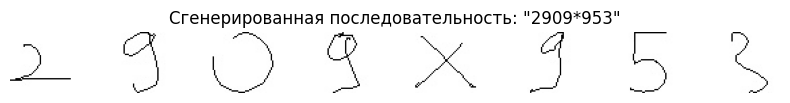

In [7]:
sequence, images = generator.generate_sequence(length=8)
sequence_image = create_sequence_image(images, spacing=30)

fig, ax = plt.subplots(1, 1, figsize=(8, 6))
ax.imshow(sequence_image, cmap='gray')
ax.set_title(f'Сгенерированная последовательность: "{sequence}"')
ax.axis('off')

plt.tight_layout()
plt.show()

Обрабатываем последовательность: '2909*953'


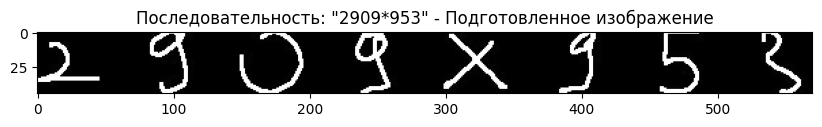

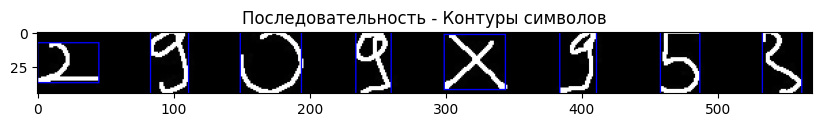

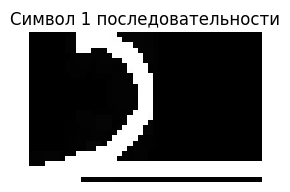

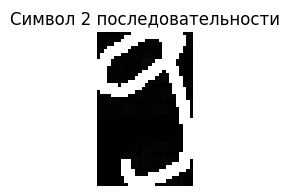

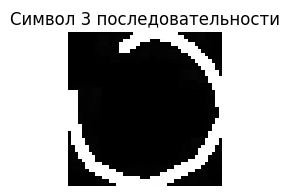

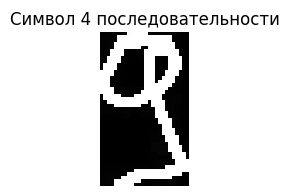

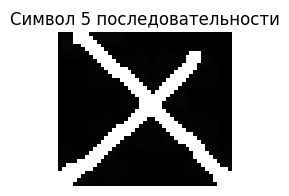

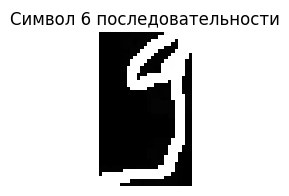

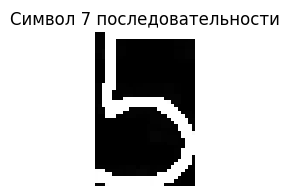

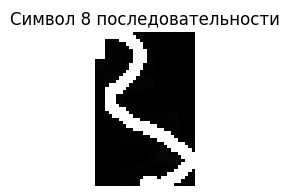

In [8]:
all_data_img = []

print(f"Обрабатываем последовательность: '{sequence}'")

img_gray = sequence_image
kernel = np.ones((3,3),np.uint8)
img_gray = cv2.erode(img_gray,kernel,iterations = 1)
img_gray = cv2.bitwise_not(img_gray)
base_size=img_gray.shape[0],img_gray.shape[1]
base=np.zeros(base_size,dtype=np.uint8)
base[0:img_gray.shape[0],0:img_gray.shape[1]]=img_gray
base = cv2.cvtColor(base, cv2.COLOR_GRAY2RGB)

img_rgb = base

plt.figure(figsize=(10, 3))
plt.imshow(img_rgb)
plt.title(f'Последовательность: "{sequence}" - Подготовленное изображение')
plt.show()

ret,thresh = cv2.threshold(img_rgb,127,255,0)
thresh = np.uint8(thresh)

contours, h = cv2.findContours(thresh[:,:,0], cv2.RETR_EXTERNAL, 2)
crops = []

contours_sorted = sorted(contours, key=lambda cnt: cv2.boundingRect(cnt)[0])

for i in range(len(contours_sorted)):
    cnt = contours_sorted[i] 
    area = cv2.contourArea(cnt)
    x,y,w,h = cv2.boundingRect(cnt)
    while (w>45):
        w-=1
    
    if w*h > 50:
        cv2.rectangle(img_rgb,(x,y),(x+w,y+h),(0,0,255),1)
        crops.append([x,y,w,h]) 

plt.figure(figsize=(10, 3))
plt.imshow(img_rgb)
plt.title(f'Последовательность - Контуры символов')
plt.show()

sequence_symbols = []
for i in range(len(crops)):
    x,y,w,h = crops[i]
    
    img_crop = img_gray[y:y+h, x:x+w]
    base = img_crop.copy()

    plt.figure(figsize=(3, 2))
    plt.imshow(base, cmap="gray")
    plt.title(f'Символ {i+1} последовательности')
    plt.axis('off')
    sequence_symbols.append((x, base))
    plt.show()

all_data_img.append({
    'sequence_text': sequence,
    'symbols': sequence_symbols
})

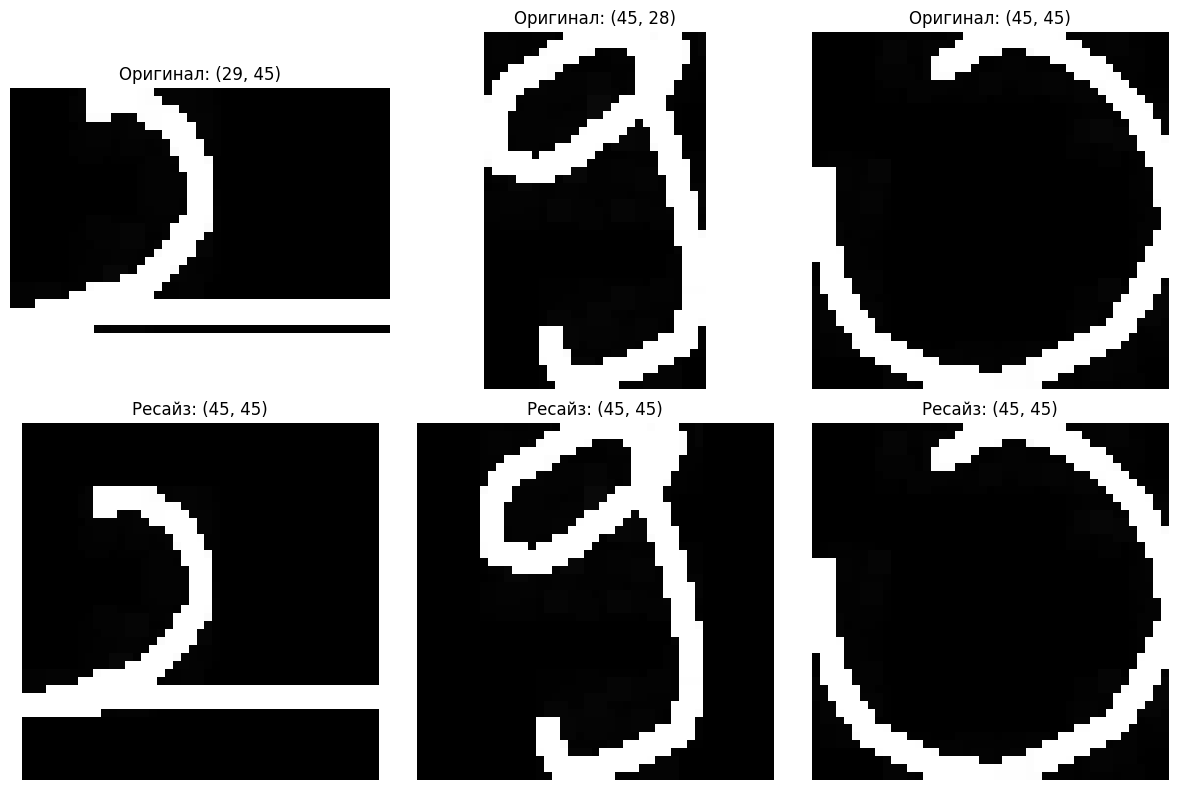

In [24]:
def center_in_45(image, target_size=45):
    h, w = image.shape
    
    squared = np.zeros((target_size, target_size), dtype=np.uint8)
    
    y_offset = (target_size - h) // 2
    x_offset = (target_size - w) // 2
    
    squared[y_offset:y_offset+h, x_offset:x_offset+w] = image
    return squared

all_data_img_45 = []

seq_data = all_data_img[0]  
sequence_text = seq_data['sequence_text']
symbols_data = seq_data['symbols']

symbols_sorted = sorted(symbols_data, key=lambda item: item[0])

resized_symbols = []
for x, symbol_img in symbols_sorted: 
    original_size = symbol_img.shape
    resized_img = center_in_45(symbol_img)
    resized_symbols.append((x, resized_img))

all_data_img_45.append({
    'sequence_text': sequence_text,
    'symbols': resized_symbols 
})

fig, axes = plt.subplots(2, 3, figsize=(12, 8))
for i in range(min(3, len(all_data_img_45[0]['symbols']))):
    orig_img = all_data_img[0]['symbols'][i][1]
    resized_img = all_data_img_45[0]['symbols'][i][1]
    
    axes[0, i].imshow(orig_img, cmap='gray')
    axes[0, i].set_title(f'Оригинал: {orig_img.shape}')
    axes[0, i].axis('off')
    
    axes[1, i].imshow(resized_img, cmap='gray')
    axes[1, i].set_title(f'Ресайз: {resized_img.shape}')
    axes[1, i].axis('off')

plt.tight_layout()
plt.show()

ЗАГРУЗКА ОБУЧАЮЩИХ ДАННЫХ
Начало загрузки данных из: C:\dataset\hw9\
Обрабатываем символ: 0  Загружено 5531 изображений
Обрабатываем символ: 1  Загружено 21216 изображений
Обрабатываем символ: 2  Загружено 20912 изображений
Обрабатываем символ: 3  Загружено 8727 изображений
Обрабатываем символ: 4  Загружено 5916 изображений
Обрабатываем символ: 5  Загружено 2836 изображений
Обрабатываем символ: 6  Загружено 2494 изображений
Обрабатываем символ: 7  Загружено 2327 изображений
Обрабатываем символ: 8  Загружено 2454 изображений
Обрабатываем символ: 9  Загружено 502 изображений
Обрабатываем символ: +  Загружено 20089 изображений
Обрабатываем символ: -  Загружено 27197 изображений
Обрабатываем символ: times  Загружено 2600 изображений
Обрабатываем символ: t  Загружено 2619 изображений
Обрабатываем символ: X  Загружено 21275 изображений
Обрабатываем символ: y  Загружено 7472 изображений
Обрабатываем символ: w  Загружено 444 изображений
Обрабатываем символ: h  Загружено 1171 изображений
Обраба

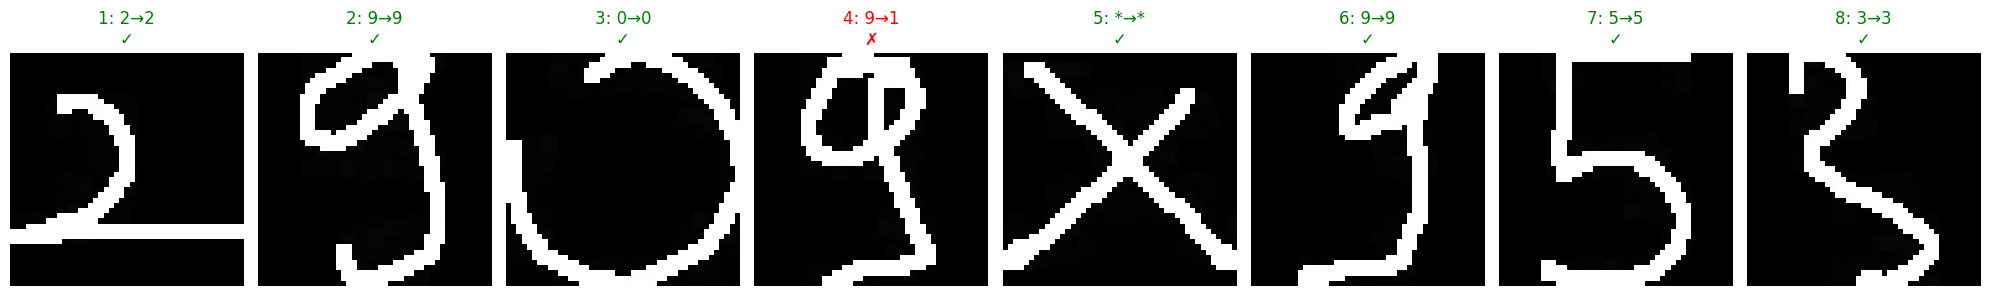

  ИТОГ: '2909*953' → '2901*953'
  Accuracy: 87.50% (7/8)

--- knn3 ---
  Символ 1: '2' → '2' ✓
  Символ 2: '9' → '3' ✗
  Символ 3: '0' → '0' ✓
  Символ 4: '9' → '1' ✗
  Символ 5: '*' → '*' ✓
  Символ 6: '9' → 'y' ✗
  Символ 7: '5' → '5' ✓
  Символ 8: '3' → '3' ✓


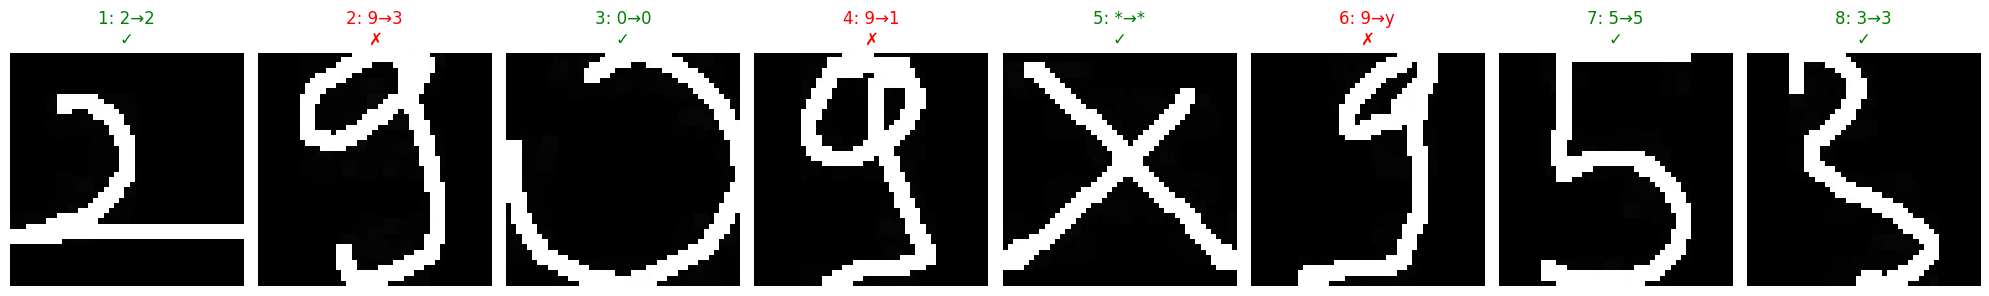

  ИТОГ: '2909*953' → '2301*y53'
  Accuracy: 62.50% (5/8)

--- knn5 ---
  Символ 1: '2' → '2' ✓
  Символ 2: '9' → '9' ✓
  Символ 3: '0' → '0' ✓
  Символ 4: '9' → '1' ✗
  Символ 5: '*' → '*' ✓
  Символ 6: '9' → 'y' ✗
  Символ 7: '5' → '5' ✓
  Символ 8: '3' → '3' ✓


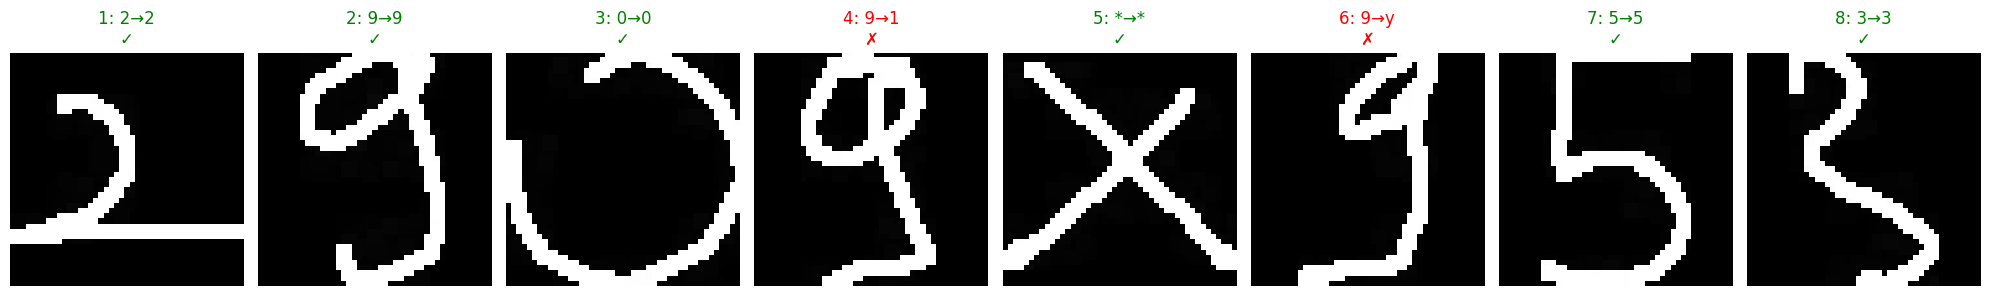

  ИТОГ: '2909*953' → '2901*y53'
  Accuracy: 75.00% (6/8)

--- knn7 ---
  Символ 1: '2' → '2' ✓
  Символ 2: '9' → '9' ✓
  Символ 3: '0' → '0' ✓
  Символ 4: '9' → '3' ✗
  Символ 5: '*' → '*' ✓
  Символ 6: '9' → '1' ✗
  Символ 7: '5' → '5' ✓
  Символ 8: '3' → '3' ✓


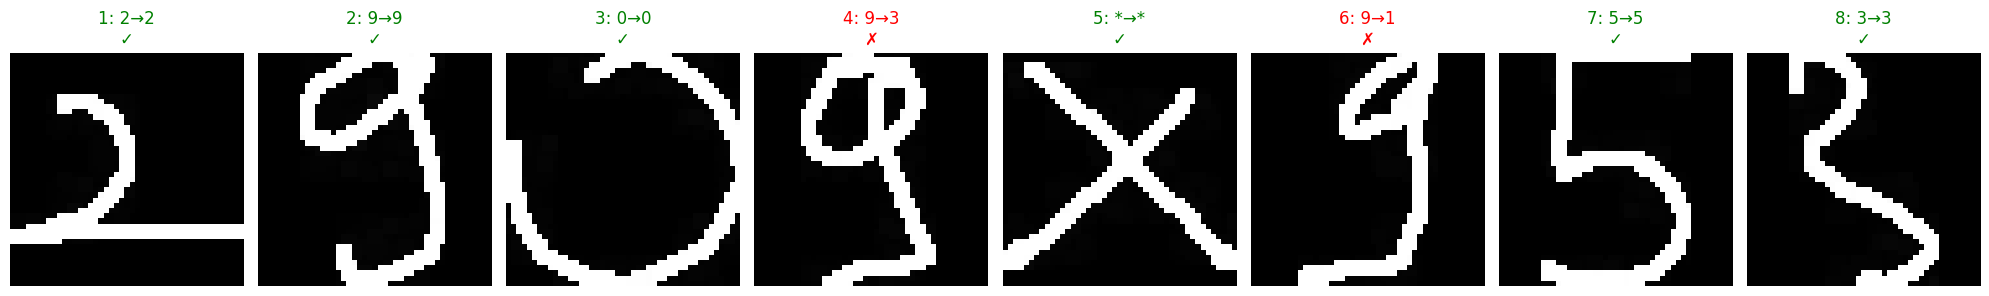

  ИТОГ: '2909*953' → '2903*153'
  Accuracy: 75.00% (6/8)

СВОДНЫЙ ОТЧЕТ ПО ВСЕМ ПОСЛЕДОВАТЕЛЬНОСТЯМ

 ОБЩАЯ СТАТИСТИКА ПО МОДЕЛЯМ:
----------------------------------------------------------------------
knn1  | Средняя: 87.50% | Лучшая: 87.50% | Худшая: 87.50%
       | Общая точность: 87.50% | Правильно: 7/8
       --------------------------------------------------
knn5  | Средняя: 75.00% | Лучшая: 75.00% | Худшая: 75.00%
       | Общая точность: 75.00% | Правильно: 6/8
       --------------------------------------------------
knn7  | Средняя: 75.00% | Лучшая: 75.00% | Худшая: 75.00%
       | Общая точность: 75.00% | Правильно: 6/8
       --------------------------------------------------
knn3  | Средняя: 62.50% | Лучшая: 62.50% | Худшая: 62.50%
       | Общая точность: 62.50% | Правильно: 5/8
       --------------------------------------------------

 ЛУЧШАЯ МОДЕЛЬ: knn1
   Средняя точность: 87.50%

РЕЗУЛЬТАТЫ ЛУЧШЕЙ МОДЕЛИ (knn1) НА ВСЕХ ПОСЛЕДОВАТЕЛЬНОСТЯХ


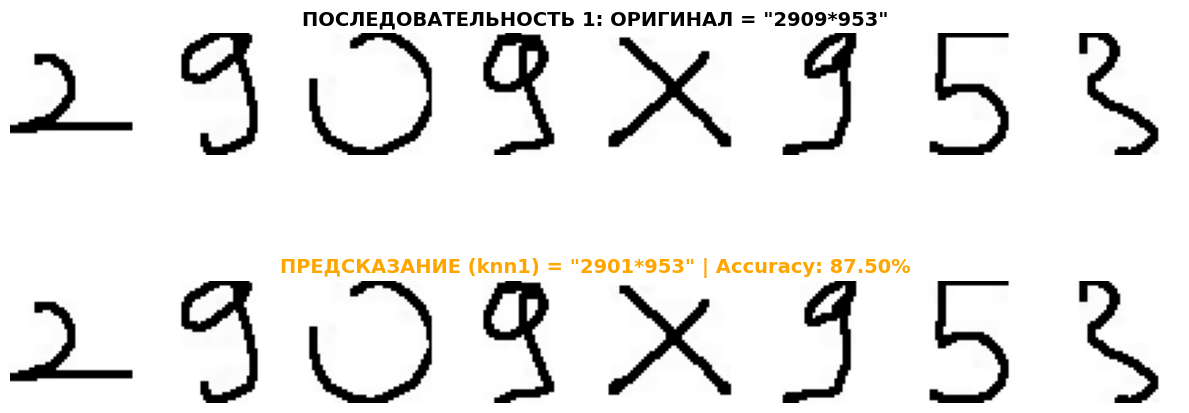


Последовательность 1:
  Оригинал:    '2909*953'
  Предсказано: '2901*953'
  Точность: 87.50%


In [32]:
from sklearn.neighbors import KNeighborsClassifier

def load_training_data(data_path, symbols, train_size=0.7):
    X_train, y_train = [], []
    
    print(f"Начало загрузки данных из: {data_path}")
    total_images = 0
    
    for symbol in symbols:
        symbol_path = os.path.join(data_path, symbol)
        print(f"Обрабатываем символ: {symbol}", end="")
        
        if not os.path.exists(symbol_path):
            print(f"  Директория не существует")
            continue
            
        images = [f for f in os.listdir(symbol_path) if os.path.isfile(os.path.join(symbol_path, f))]
        images.sort()
        
        split_idx = int(len(images) * train_size)
        train_images = images[:split_idx]
        
        symbol_count = 0
        for img_name in train_images:
            img_path = os.path.join(symbol_path, img_name)
            img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
            if img is not None:
                X_train.append(img.flatten())
                current_symbol = symbol
                if symbol == 'X':
                    current_symbol = 'x'
                elif symbol == 'times':
                    current_symbol = '*'
                y_train.append(current_symbol)
                symbol_count += 1
                total_images += 1
        
        print(f"  Загружено {symbol_count} изображений")
    
    print(f"Загрузка завершена. Всего загружено: {len(X_train)} изображений")
    return np.array(X_train), np.array(y_train)

# Загрузка данных для обучения
print("=" * 50)
print("ЗАГРУЗКА ОБУЧАЮЩИХ ДАННЫХ")
print("=" * 50)

symbols = ['0','1','2','3','4','5','6','7','8','9','+','-','times','t','X','y','w','h','(',')',',']
X_train, y_train = load_training_data('C:\\dataset\\hw9\\', symbols, 0.8)

print(f" Обучающая выборка: {len(X_train)} изображений")

# Создание и обучение моделей k-NN
print("\n" + "=" * 50)
print("ОБУЧЕНИЕ МОДЕЛЕЙ K-NN")
print("=" * 50)

knn1 = KNeighborsClassifier(n_neighbors=1)
knn3 = KNeighborsClassifier(n_neighbors=3)
knn5 = KNeighborsClassifier(n_neighbors=5)
knn7 = KNeighborsClassifier(n_neighbors=7)

print("Обучение модели k=1...")
knn1.fit(X_train, y_train)
print(" Модель k = 1 успешно обучена!")

print("Обучение модели k=3...")
knn3.fit(X_train, y_train)
print(" Модель k = 3 успешно обучена!")

print("Обучение модели k=5...")
knn5.fit(X_train, y_train)
print(" Модель k = 5 успешно обучена!")

print("Обучение модели k=7...")
knn7.fit(X_train, y_train)
print(" Модель k = 7 успешно обучена!")

# Функция для предсказания символов
def predict_symbol(model, image):
    image = cv2.bitwise_not(image)
    img_flat = image.flatten()
    prediction = model.predict([img_flat])
    return prediction[0]

# Тестирование на множестве последовательностей с картинками
print("\n" + "=" * 60)
print("ТЕСТИРОВАНИЕ НА МНОЖЕСТВЕ ПОСЛЕДОВАТЕЛЬНОСТЕЙ")
print("=" * 60)

if 'all_data_img_45' in locals() and len(all_data_img_45) > 0:
    all_results = []
    
    print(f"Всего последовательностей для тестирования: {len(all_data_img_45)}")
    
    # Тестируем на всех последовательностях
    for seq_idx, seq_data in enumerate(all_data_img_45):
        original_text = seq_data['sequence_text']
        symbols_data = seq_data['symbols']

        print(f"\n{'='*60}")
        print(f"ПОСЛЕДОВАТЕЛЬНОСТЬ {seq_idx + 1}/{len(all_data_img_45)}: '{original_text}'")
        print(f"{'='*60}")
        
        models = {
            'knn1': knn1,
            'knn3': knn3, 
            'knn5': knn5,
            'knn7': knn7
        }

        seq_results = {}

        # Для каждой модели делаем предсказание
        for model_name, model in models.items():
            predicted_symbols = []
            
            print(f"\n--- {model_name} ---")
            
            # Создаем фигуру для отображения символов этой последовательности
            fig, axes = plt.subplots(1, len(symbols_data), figsize=(15, 3))
            if len(symbols_data) == 1:
                axes = [axes]
            elif len(symbols_data) > 5:  # Если символов много, уменьшаем размер
                fig.set_size_inches(20, 3)
            
            for j, (x, symbol_img) in enumerate(symbols_data):
                predicted_char = predict_symbol(model, symbol_img)
                predicted_symbols.append(predicted_char)
                
                # Отображаем символ
                axes[j].imshow(symbol_img, cmap='gray')
                original_char = original_text[j] if j < len(original_text) else '?'
                status = "✓" if original_char == predicted_char else "✗"
                color = "green" if original_char == predicted_char else "red"
                axes[j].set_title(f'{j+1}: {original_char}→{predicted_char}\n{status}', color=color)
                axes[j].axis('off')
                
                print(f"  Символ {j+1}: '{original_char}' → '{predicted_char}' {status}")
            
            plt.tight_layout()
            plt.show()
            
            predicted_text = ''.join(predicted_symbols)
            
            correct_chars = sum(1 for orig, pred in zip(original_text, predicted_text) if orig == pred)
            total_chars = len(original_text)
            accuracy = correct_chars / total_chars
            
            print(f"  ИТОГ: '{original_text}' → '{predicted_text}'")
            print(f"  Accuracy: {accuracy:.2%} ({correct_chars}/{total_chars})")
            
            seq_results[model_name] = {
                'predicted_text': predicted_text,
                'accuracy': accuracy,
                'correct_chars': correct_chars,
                'total_chars': total_chars
            }
        
        all_results.append({
            'sequence': original_text,
            'results': seq_results
        })

    # Сводный отчет по всем последовательностям
    print(f"\n{'='*80}")
    print("СВОДНЫЙ ОТЧЕТ ПО ВСЕМ ПОСЛЕДОВАТЕЛЬНОСТЯМ")
    print(f"{'='*80}")
    
    # Статистика по моделям
    model_stats = {}
    
    for model_name in models.keys():
        accuracies = [seq['results'][model_name]['accuracy'] for seq in all_results]
        total_correct = sum(seq['results'][model_name]['correct_chars'] for seq in all_results)
        total_chars = sum(seq['results'][model_name]['total_chars'] for seq in all_results)
        
        model_stats[model_name] = {
            'avg_accuracy': np.mean(accuracies),
            'min_accuracy': np.min(accuracies),
            'max_accuracy': np.max(accuracies),
            'total_accuracy': total_correct / total_chars,
            'total_correct': total_correct,
            'total_chars': total_chars
        }
    
    # Вывод общей статистики
    print(f"\n ОБЩАЯ СТАТИСТИКА ПО МОДЕЛЯМ:")
    print("-" * 70)
    
    sorted_stats = sorted(model_stats.items(), key=lambda x: x[1]['avg_accuracy'], reverse=True)
    
    for model_name, stats in sorted_stats:
        print(f"{model_name:5} | Средняя: {stats['avg_accuracy']:6.2%} | Лучшая: {stats['max_accuracy']:6.2%} | Худшая: {stats['min_accuracy']:6.2%}")
        print(f"       | Общая точность: {stats['total_accuracy']:6.2%} | Правильно: {stats['total_correct']}/{stats['total_chars']}")
        print("       " + "-" * 50)
    
    # Визуализация результатов лучшей модели
    best_model_name = sorted_stats[0][0]
    best_model_stats = sorted_stats[0][1]
    
    print(f"\n ЛУЧШАЯ МОДЕЛЬ: {best_model_name}")
    print(f"   Средняя точность: {best_model_stats['avg_accuracy']:.2%}")
    
    # Показываем все последовательности с результатами лучшей модели
    print(f"\n{'='*80}")
    print(f"РЕЗУЛЬТАТЫ ЛУЧШЕЙ МОДЕЛИ ({best_model_name}) НА ВСЕХ ПОСЛЕДОВАТЕЛЬНОСТЯХ")
    print(f"{'='*80}")
    
    for seq_idx, seq_data in enumerate(all_data_img_45):
        original_text = seq_data['sequence_text']
        symbols_data = seq_data['symbols']
        
        # Предсказание лучшей моделью
        predicted_symbols = []
        for j, (x, symbol_img) in enumerate(symbols_data):
            predicted_char = predict_symbol(models[best_model_name], symbol_img)
            predicted_symbols.append(predicted_char)
        predicted_text = ''.join(predicted_symbols)
        
        accuracy = all_results[seq_idx]['results'][best_model_name]['accuracy']
        
        # Создаем визуализацию
        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6))
        
        # Оригинальная последовательность
        original_sequence_img = create_sequence_image([cv2.bitwise_not(img) for x, img in symbols_data], spacing=10)
        ax1.imshow(original_sequence_img, cmap='gray')
        ax1.set_title(f'ПОСЛЕДОВАТЕЛЬНОСТЬ {seq_idx + 1}: ОРИГИНАЛ = "{original_text}"', fontsize=14, fontweight='bold')
        ax1.axis('off')
        
        # Предсказанная последовательность
        ax2.imshow(original_sequence_img, cmap='gray')
        ax2.set_title(f'ПРЕДСКАЗАНИЕ ({best_model_name}) = "{predicted_text}" | Accuracy: {accuracy:.2%}', 
                     fontsize=14, fontweight='bold', 
                     color='green' if accuracy == 1.0 else 'orange' if accuracy >= 0.7 else 'red')
        ax2.axis('off')
        
        # Подсвечиваем разными цветами в зависимости от точности
        border_color = 'green' if accuracy == 1.0 else 'orange' if accuracy >= 0.7 else 'red'
        for ax in [ax1, ax2]:
            for spine in ax.spines.values():
                spine.set_edgecolor(border_color)
                spine.set_linewidth(3)
        
        plt.tight_layout()
        plt.show()
        
        # Выводим детали по символам
        print(f"\nПоследовательность {seq_idx + 1}:")
        print(f"  Оригинал:    '{original_text}'")
        print(f"  Предсказано: '{predicted_text}'")
        print(f"  Точность: {accuracy:.2%}")

else:
    print("Нет данных последовательностей для тестирования!")
    print("Убедитесь, что переменная all_data_img_45 существует и содержит данные")